## baseline_06: Introducing categorical features to the model
- This baseline model will do two new things:
  - Expand across multiple cartridges
  - Provide a categorical feature for the model to assess
- Will use OneHotEncoding for the categorical feature
- Will test how the model handles a much more diverse dataset

In [33]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv("ridge_dataset.csv")
df.head()

,cartridge,bullet_diameter,bullet_brand,bullet_type,bullet_weight,powder_type,burn_rate_index,charge_weight,velocity_fps,coal
0,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n130,84,21.1,3402,2.181
1,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n133,89,22.8,3481,2.181
2,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n135,102,24.7,3514,2.181
3,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n140,112,26.2,3425,2.181
4,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n540,117,25.8,3301,2.181


In [38]:
numeric_features = ["charge_weight", "bullet_weight", "burn_rate_index"]
categoric_features = ["cartridge"]
target = "velocity_fps"

X = df[numeric_features + categoric_features]
y = df[target].astype(float)

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoric_features)
    ]
)



In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (2789, 4)  Test: (698, 4)


In [41]:
mean_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())
floor_mae = mean_absolute_error(y_test, mean_pred)
print(f"FLOOR MAE (test): {floor_mae:.2f}ft/s")

model = Pipeline([
    ("preprocess", preprocessor),
    ("ridge", Ridge(alpha=1.0))
])


model.fit(X_train, y_train)
preds = model.predict(X_test)

model_mae = mean_absolute_error(y_test, preds)
print(f"MODEL MAE (test): {model_mae:.2f}ft/s")

FLOOR MAE (test): 269.91ft/s
MODEL MAE (test): 85.86ft/s


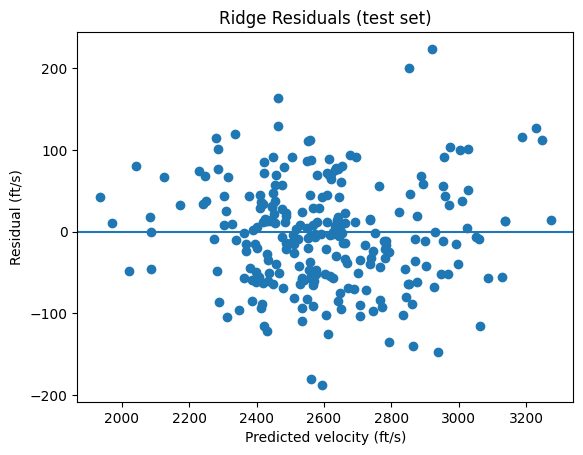

In [28]:
residuals = y_test.to_numpy() - preds

plt.scatter(preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted velocity (ft/s)")
plt.ylabel("Residual (ft/s)")
plt.title("Ridge Residuals (test set)")
plt.show()